In [1]:
import ee
ee.Authenticate()
ee.Initialize()

In [2]:
import folium
import numpy as np

roi_center = [-70, -33.8719]
roi = ee.Geometry.Point(roi_center)

# Load Landsat 8 image collection, filter by date and region
landsat = ee.ImageCollection("LANDSAT/LC08/C02/T1_TOA").filterDate('2024-01-24', '2024-02-24')#.filterBounds(roi)

bands = ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B9', 'B10', 'B11']
image_all_bands = landsat.median().select(bands)

vis_params = {
    'min': 0,
    'max': 0.3,
    'bands': ['B1'],
}

# Create a folium map centered at the region of interest
# (es necesario el np.flip, las coordenadas estan invertidas en relacion al otro)
m = folium.Map(location=np.flip(roi_center), zoom_start=7)

# Add the image layer to the map
map_id_dict = ee.Image(image_all_bands).getMapId(vis_params)
folium.TileLayer(
    tiles=map_id_dict['tile_fetcher'].url_format,
    attr='Google Earth Engine',
    name='Landsat 8 True Color',
    overlay=True,
    control=True
).add_to(m)

print(map_id_dict['tile_fetcher'].url_format)

# Add layer control
m.add_child(folium.LayerControl())

# Display the map
m


https://earthengine.googleapis.com/v1/projects/318208787481/maps/55a58a29a38f04ab8b667dfcfd7f2348-a4bb0773a7b277d28933cd45fba41ee3/tiles/{z}/{x}/{y}


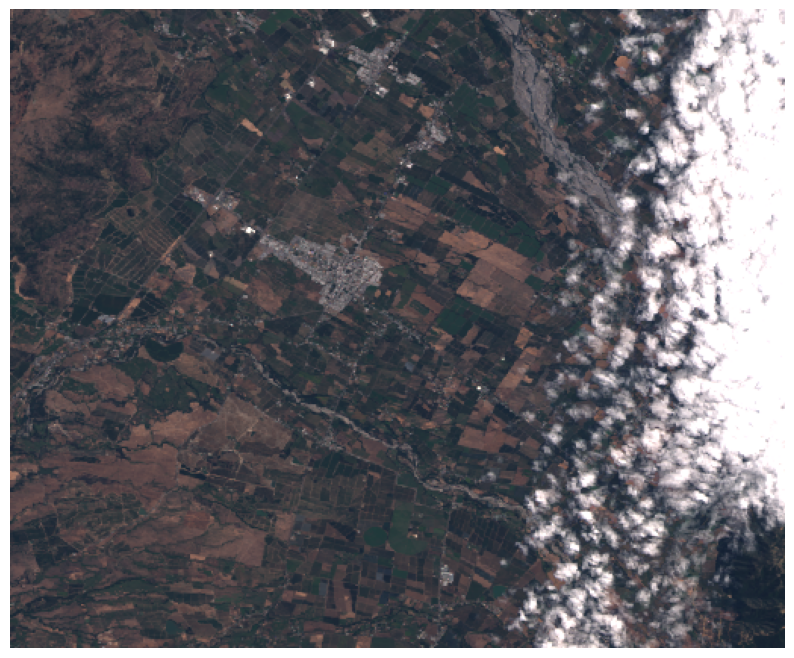

In [3]:
from PIL import Image
import requests

# roi = ee.Geometry.Point([-70.56, -33.52]) # Santiago, Chile
# -35.13008839,-71.26624015
roi = ee.Geometry.Point([-71.26624015, -35.13008839]) # Talca, Chile
landsat = ee.ImageCollection("LANDSAT/LC08/C02/T1_TOA").filterDate('2024-01-24', '2024-03-24').filterBounds(roi)
# image = landsat.median().select(['B4', 'B3', 'B2'])

# Get all bands
bands = ['B4', 'B3', 'B2']
image = landsat.median().select(bands)

region = roi.buffer(10000).bounds().getInfo()

url = image.getThumbUrl({
    'region': region['coordinates'],
    'dimensions': 512,
    'format': 'png',
    'min': 0,
    'max': 0.4,
})
img = Image.open(requests.get(url, stream=True).raw)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis('off')
plt.show()



In [4]:
# print(image.getInfo())
# {'type': 'Image', 'bands': [{'id': 'B1', 'data_type': {'type': 'PixelType', 'precision': 'float'}, 
# 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}, {'id': 'B2', 'data_type': {'type': 'PixelType', 'precision': 'float'},
# 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}, {'id': 'B3', 'data_type': {'type': 'PixelType', 'precision': 'float'},
# 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}, {'id': 'B4', 'data_type': {'type': 'PixelType', 'precision': 'float'},
# 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}, {'id': 'B5', 'data_type': {'type': 'PixelType', 'precision': 'float'},
# 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}, {'id': 'B6', 'data_type': {'type': 'PixelType', 'precision': 'float'},
# 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}, {'id': 'B7', 'data_type': {'type': 'PixelType', 'precision': 'float'},
# 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}, {'id': 'B8', 'data_type': {'type': 'PixelType', 'precision': 'float'},
# 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}, {'id': 'B9', 'data_type': {'type': 'PixelType', 'precision': 'float'},
# 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}]}


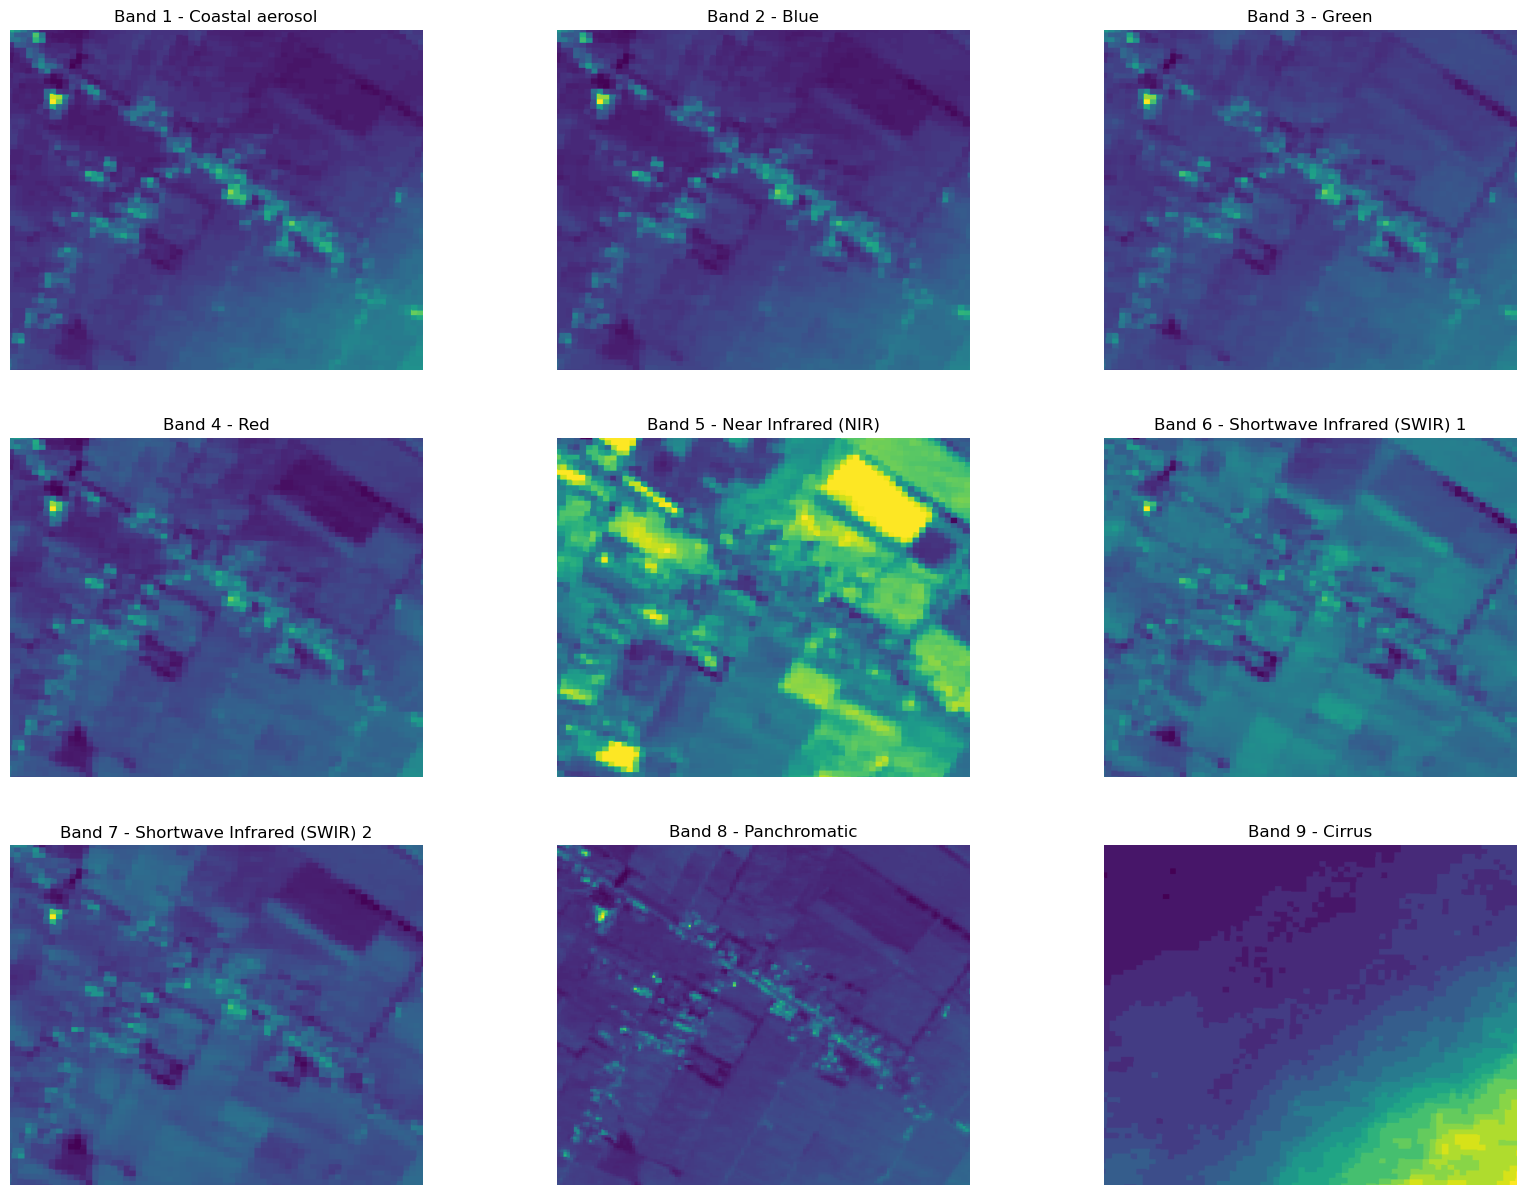

In [5]:
# Plot each band
import matplotlib.pyplot as plt
import numpy as np
from io import BytesIO

bands = ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B9']
band_names = [
    'Band 1 - Coastal aerosol', # 0.43-0.45 30',
    'Band 2 - Blue',  #0.45-0.51 30',
    'Band 3 - Green', # 0.53-0.59 30',
    'Band 4 - Red', # 0.64-0.67 30',
    'Band 5 - Near Infrared (NIR)', # 0.85-0.88 30',
    'Band 6 - Shortwave Infrared (SWIR) 1', # 1.57-1.65 30',
    'Band 7 - Shortwave Infrared (SWIR) 2', # 2.11-2.29 30',
    'Band 8 - Panchromatic', # 0.50-0.68 15',
    'Band 9 - Cirrus', # 1.36-1.38 30'
]
roi = ee.Geometry.Point([-71.26624015, -35.13008839]) # Talca, Chile
image = (ee.ImageCollection("LANDSAT/LC08/C02/T1_TOA")
           .filterDate('2024-08-24', '2024-09-24')
           .filterBounds(roi)
        #    .filter(ee.Filter.lt('CLOUD_COVER', 10))
           .median()
           .select(bands)
)

# Convert the image to a real ndarray with all bands
region = roi.buffer(1000).bounds().getInfo()

# Prepare the request URL for all bands
urls = []
for i in range(0, len(bands), 3):
    batch = bands[i:i+3]
    url = image.getThumbUrl({
        'region': region['coordinates'],
        'dimensions': '512',
        'format': 'png',
        'min': 0,
        'max': 0.4,
        'bands': batch
    })
    urls.append(url)

# Fetch the images in a single batch and convert to ndarray
ndarr_real = np.zeros((422, 512, len(bands)))
for i, url in enumerate(urls):
    response = requests.get(url)
    img = Image.open(BytesIO(response.content))
    ndarr_real[:, :, i*3:i*3+3] = np.array(img)

# Plot the bands
fig, axs = plt.subplots(3, 3, figsize=(20, 15))
for i, band in enumerate(bands):
    ax = axs[i//3, i%3]
    ax.imshow(ndarr_real[:, :, i], interpolation='bilinear')
    ax.axis('off')
    ax.set_title(band_names[i])
plt.show()

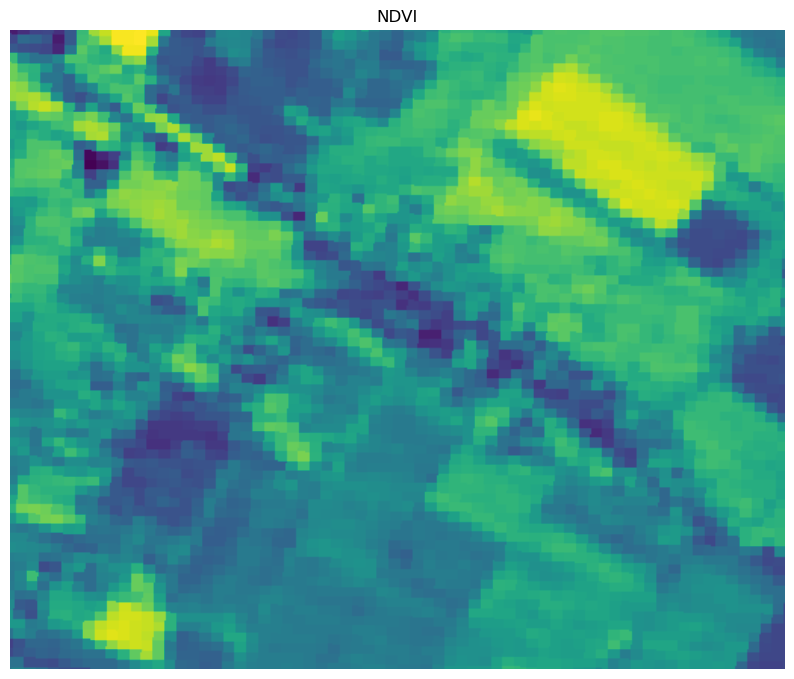

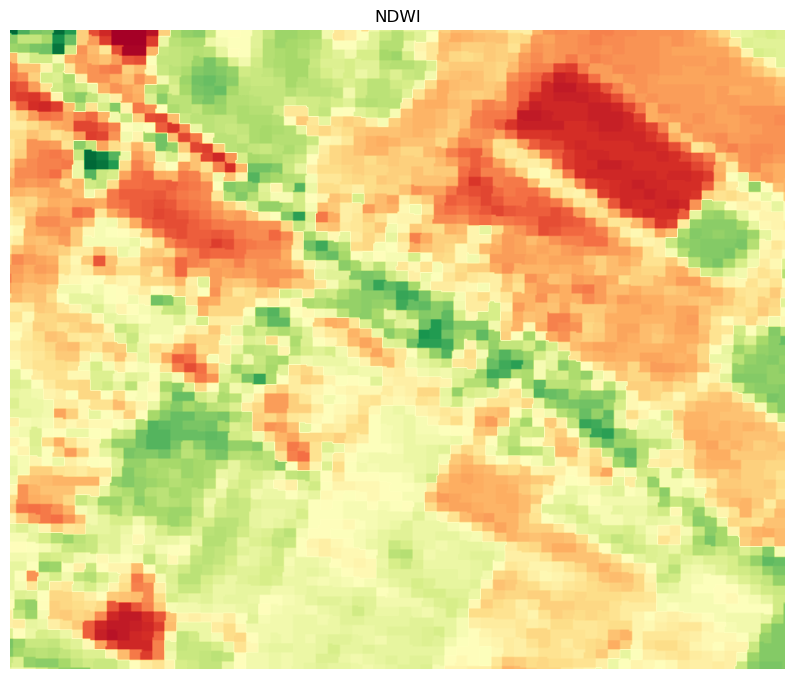

In [6]:
# Comput NDVI
ndvi = image.normalizedDifference(['B5', 'B4'])
url = ndvi.getThumbUrl({
    'region': region['coordinates'],
    'dimensions': '512',
    'format': 'png',
    'min': -1,
    'max': 1,
})
response = requests.get(url)
img = Image.open(BytesIO(response.content))
ndarr = np.array(img)

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(ndarr, interpolation='bilinear')
ax.axis('off')
ax.set_title('NDVI')
plt.show()

# Compute NDWI
ndwi = image.normalizedDifference(['B3', 'B5'])
url = ndwi.getThumbUrl({
    'region': region['coordinates'],
    'dimensions': '512',
    'format': 'png',
    'min': -1,
    'max': 1,
})
response = requests.get(url)
img = Image.open(BytesIO(response.content))
ndarr = np.array(img)

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(ndarr, interpolation='bilinear', cmap='RdYlGn')
ax.axis('off')
ax.set_title('NDWI')
plt.show()


In [7]:
# Make slider for data range, +-1° lat & long from center of roi
import ipywidgets as widgets

# 35°08'03"S 71°15'30"W


def update_image(lat=roi_center[1], lon=roi_center[0]):
    roi = ee.Geometry.Point([lon, lat])
    landsat = ee.ImageCollection("LANDSAT/LC08/C02/T1_TOA").filterDate('2024-01-24', '2024-03-24').filterBounds(roi)
    image = landsat.median().select(['B4', 'B3', 'B2'])
    
    region = roi.buffer(10000).bounds().getInfo()
    
    url = image.getThumbUrl({
        'region': region['coordinates'],
        'dimensions': 512,
        'format': 'png',
        'min': 0,
        'max': 0.3,
    })
    
    img = Image.open(requests.get(url, stream=True).raw)
    
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

widgets.interact(update_image, lat=(roi_center[1]-1, roi_center[1]+1, 0.1), lon=(roi_center[0]-1, roi_center[0]+1, 0.1))


interactive(children=(FloatSlider(value=-33.8719, description='lat', max=-32.8719, min=-34.8719), FloatSlider(…

<function __main__.update_image(lat=-33.8719, lon=-70)>

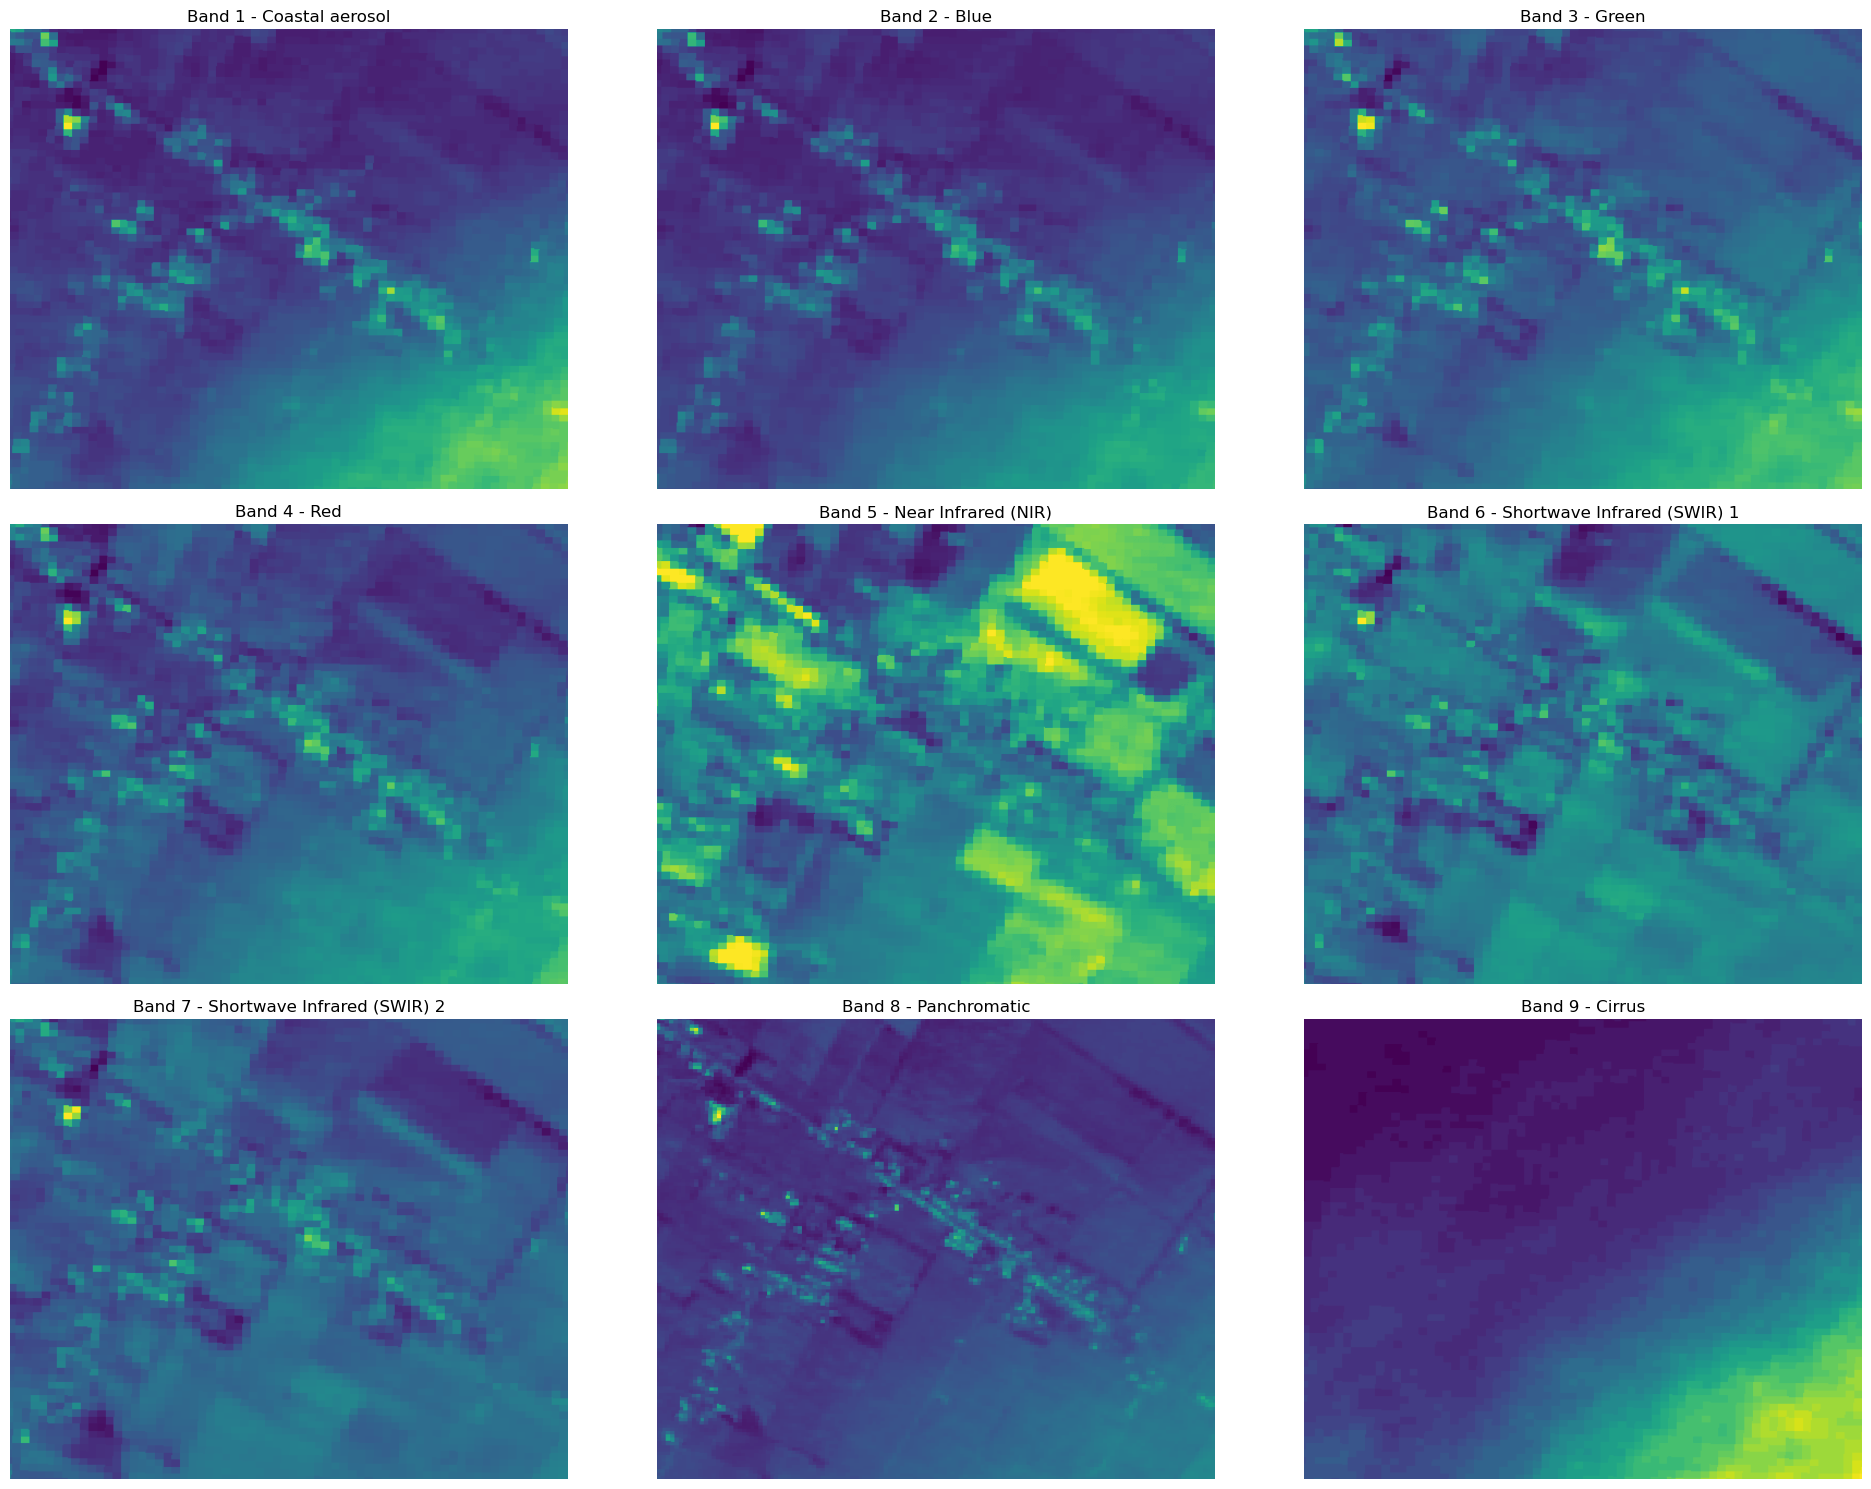

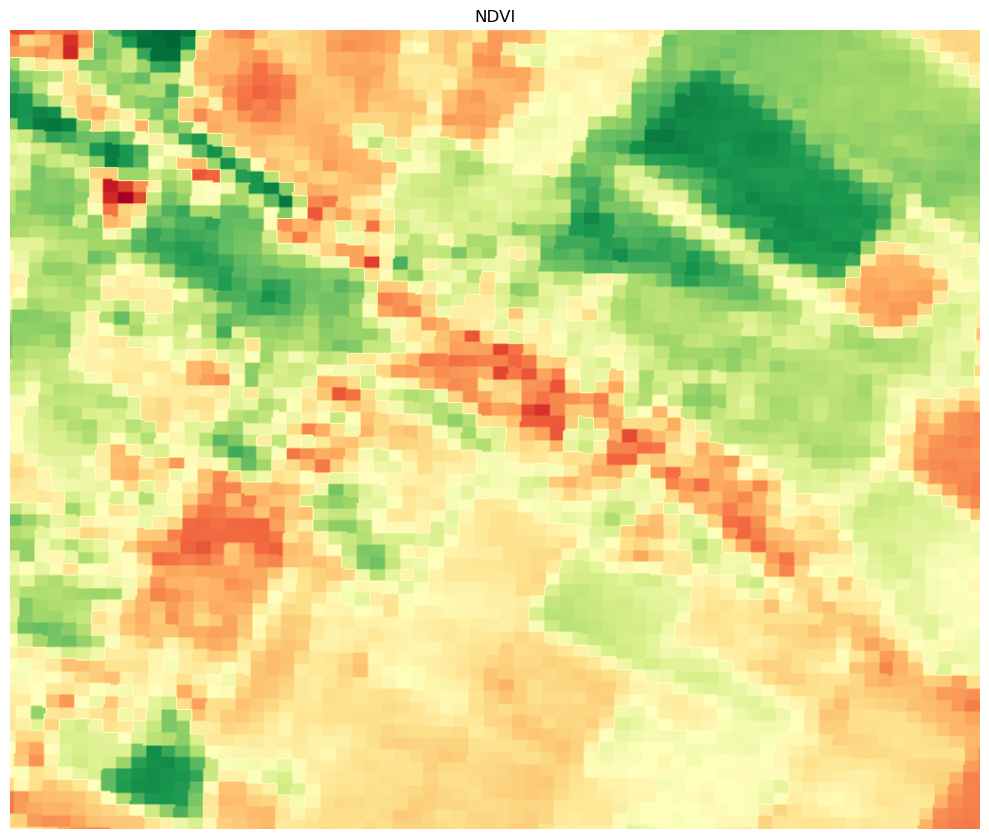

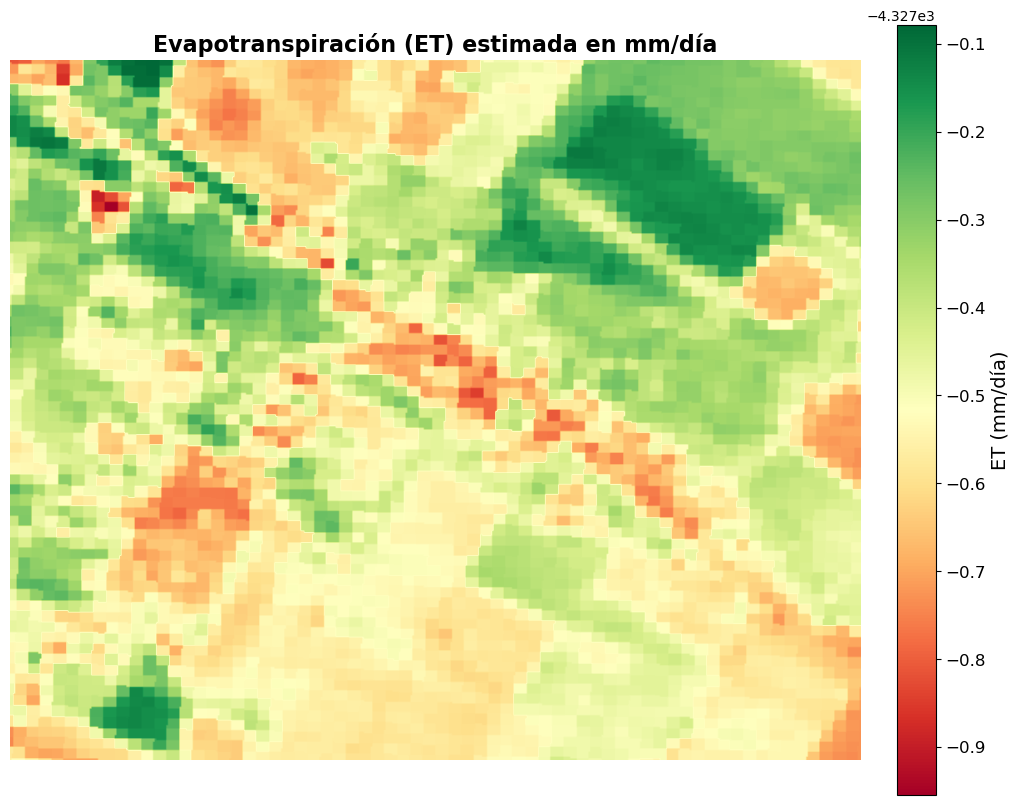

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import requests
from io import BytesIO
from PIL import Image
import ee

# Inicializar Earth Engine
ee.Initialize()

# Definir las bandas
bands = ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B9']
band_names = [
    'Band 1 - Coastal aerosol',
    'Band 2 - Blue',
    'Band 3 - Green',
    'Band 4 - Red',
    'Band 5 - Near Infrared (NIR)',
    'Band 6 - Shortwave Infrared (SWIR) 1',
    'Band 7 - Shortwave Infrared (SWIR) 2',
    'Band 8 - Panchromatic',
    'Band 9 - Cirrus'
]

# Definir la región de interés
roi = ee.Geometry.Point([-71.26624015, -35.13008839])  # Talca, Chile
image = (ee.ImageCollection("LANDSAT/LC08/C02/T1_TOA")
           .filterDate('2024-08-01', '2024-09-17')
           .filterBounds(roi)
           .median()
           .select(bands))

# Convertir la imagen a un ndarray real con todas las bandas
region = roi.buffer(1000).bounds().getInfo()

# Preparar la URL de solicitud para todas las bandas
urls = []
for i in range(0, len(bands), 3):
    batch = bands[i:i+3]
    url = image.getThumbUrl({
        'region': region['coordinates'],
        'dimensions': '512',
        'format': 'png',
        'min': 0,
        'max': 0.4,
        'bands': batch
    })
    urls.append(url)

# Obtener las imágenes en un solo lote y convertir a ndarray
ndarr_real = np.zeros((422, 512, len(bands)))
for i, url in enumerate(urls):
    response = requests.get(url)
    img = Image.open(BytesIO(response.content))
    ndarr_real[:, :, i*3:i*3+3] = np.array(img) / 255.0  # Normalizar a [0,1]

def calculate_et(NDVI):
    # Calcular R_n (Radiación neta) - Suponiendo valores ficticios
    # Asumimos que R_n es la radiación reflejada en las bandas visibles
    R_n = 0.5  # Valor ficticio para R_n en W/m²

    # Calcular G (Flujo de calor en el suelo) usando NDVI
    G = R_n * (0.05 + 0.18 * np.exp(-0.521 * NDVI))

    # Calcular H (Flujo de calor sensible) - Valores ficticios
    T_s = 300  # Suponiendo una temperatura superficial en K
    T_a = 295  # Suponiendo una temperatura del aire en K
    rho = 1.225  # Densidad del aire (kg/m³)
    C_p = 1005  # Calor específico del aire (J/kg/K)

    # Resistencia aerodinámica - valor ficticio
    r_a = 50  # m/s

    H = (rho * C_p * (T_s - T_a)) / r_a  # Simplificación del flujo sensible

    # Calor latente de vaporización (λ)
    lambda_value = 2.45e6  # J/kg

    # Calcular ET
    ET = (R_n - G - H) / lambda_value

    return ET

# Calcular NDVI
B4 = ndarr_real[:, :, 3]  # Band 4 - Rojo
B5 = ndarr_real[:, :, 4]  # Band 5 - NIR

NDVI = (B5 - B4) / (B5 + B4)

# Calcular ET usando la función
ET = calculate_et(NDVI)

# Visualizar resultados
fig, axs = plt.subplots(3, 3, figsize=(20, 15))

# Mostrar las bandas originales
for i, band in enumerate(bands):
    ax = axs[i//3, i%3]
    ax.imshow(ndarr_real[:, :, i], interpolation='bilinear')
    ax.axis('off')
    ax.set_title(band_names[i])

plt.tight_layout()
plt.show()

# Mostrar NDVI
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(NDVI, cmap='RdYlGn', interpolation='bilinear')
ax.axis('off')
ax.set_title('NDVI')
plt.tight_layout()
plt.show()

# Convert ET from m/s to mm/day
ET_mm_day = ET * 86400 * 1000  # 86400 seconds in a day, 1000 mm in a meter

# Plot ET in mm/day
plt.figure(figsize=(12, 10))
plt.imshow(ET_mm_day, cmap='RdYlGn', interpolation='bilinear')
plt.axis('off')
plt.title('Evapotranspiración (ET) estimada en mm/día', fontsize=16, fontweight='bold')
cbar = plt.colorbar(fraction=0.046, pad=0.04)
cbar.set_label('ET (mm/día)', fontsize=14)
cbar.ax.tick_params(labelsize=12)
plt.show()


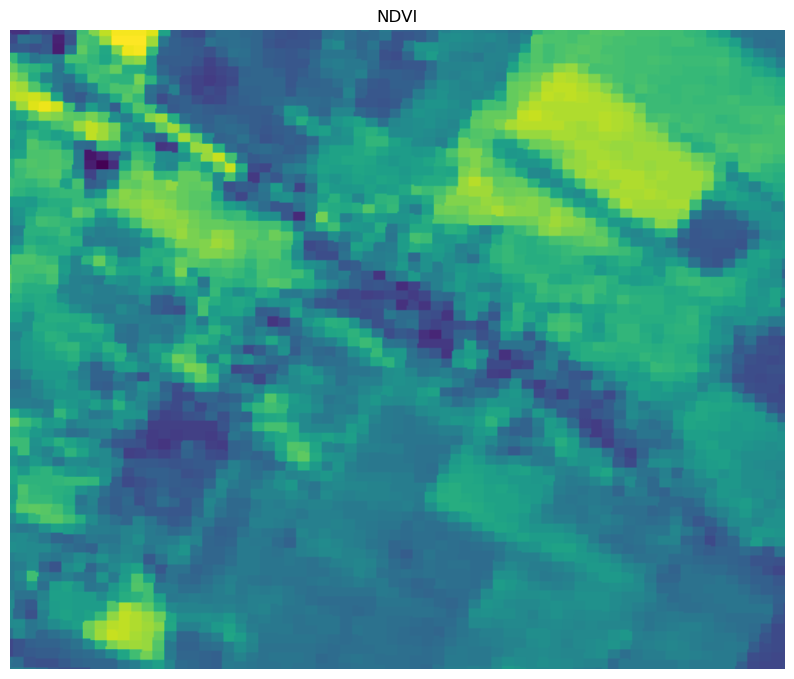

(422, 512)


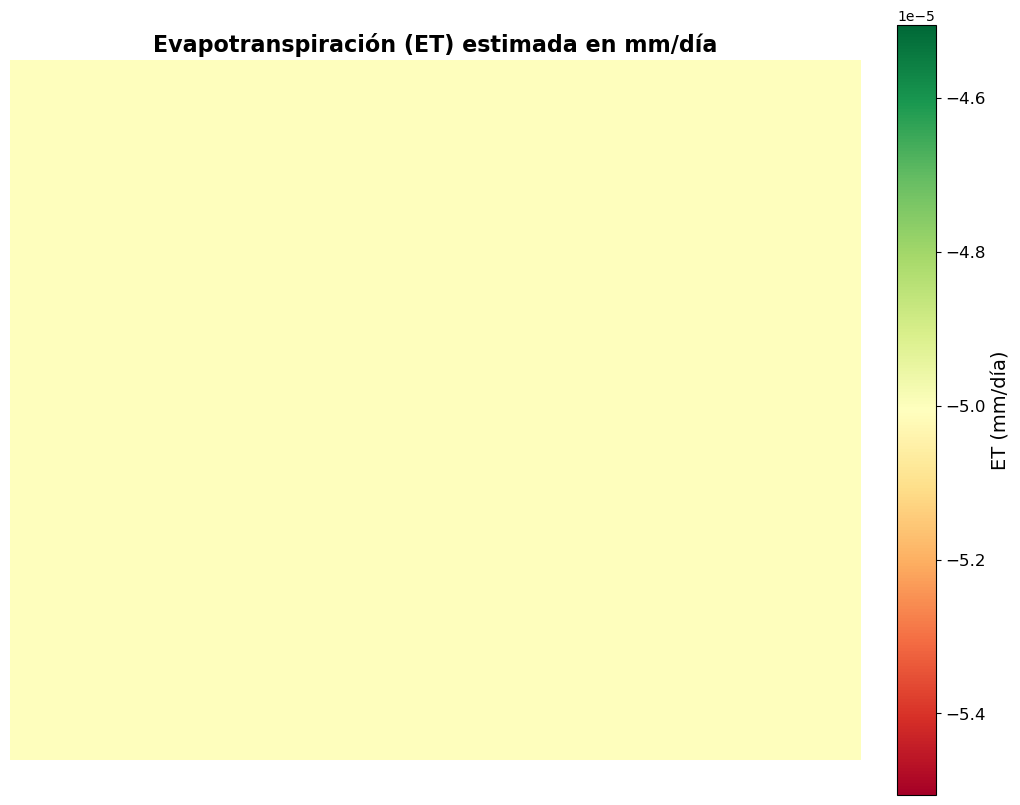

In [9]:
# Definir las bandas
bands = ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B9']
band_names = [
    'Band 1 - Coastal aerosol',
    'Band 2 - Blue',
    'Band 3 - Green',
    'Band 4 - Red',
    'Band 5 - Near Infrared (NIR)',
    'Band 6 - Shortwave Infrared (SWIR) 1',
    'Band 7 - Shortwave Infrared (SWIR) 2',
    'Band 8 - Panchromatic',
    'Band 9 - Cirrus'
]

# Definir la región de interés
roi = ee.Geometry.Point([-71.26624015, -35.13008839])  # Talca, Chile
image = (ee.ImageCollection("LANDSAT/LC08/C02/T1_TOA")
           .filterDate('2024-08-01', '2024-09-17')
           .filterBounds(roi)
           .median()
           .select(bands))

# Convertir la imagen a un ndarray real con todas las bandas
region = roi.buffer(1000).bounds().getInfo()

ndvi_req = image.normalizedDifference(['B5', 'B4']).rename('NDVI')
url = ndvi_req.getThumbUrl({
    'region': region['coordinates'],
    'dimensions': '512',
    'format': 'png',
    'min': -1,
    'max': 1,
})
response = requests.get(url)
img = Image.open(BytesIO(response.content))
ndvi = np.array(img)

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(ndvi, interpolation='bilinear')
ax.axis('off')
ax.set_title('NDVI')
plt.show()


print(ndvi.shape)
ET = calculate_et(ndvi)

# Convert ET from m/s to mm/day
# ET_mm_day = ET * 86400 * 1000  # 86400 seconds in a day,

# Plot ET in mm/day
plt.figure(figsize=(12, 10))
plt.imshow(ET, cmap='RdYlGn', interpolation='bilinear')
plt.axis('off')
plt.title('Evapotranspiración (ET) estimada en mm/día', fontsize=16, fontweight='bold')
cbar = plt.colorbar(fraction=0.046, pad=0.04)
cbar.set_label('ET (mm/día)', fontsize=14)
cbar.ax.tick_params(labelsize=12)
plt.show()


In [10]:
et0_collection = ee.ImageCollection("NASA/POWER/ET0")
et0 = et0_collection.filterDate('2024-08-01', '2024-09-17').filterBounds(roi).mean()
print(et0.getInfo())

EEException: ImageCollection.load: ImageCollection asset 'NASA/POWER/ET0' not found (does not exist or caller does not have access).

In [11]:
m.save("mapa.html")

In [14]:
!pip install geeet geemap

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 24.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 15.4 MB/s eta 0:00:00
  Created wheel for pyperclip: filename=pyperclip-1.9.0-py3-none-any.whl size=11003 sha256=952cc06aaace3803d3121f0d4cd38b95aa2c133190edf16ff8f7943266c8935b
  Stored in directory: /home/juampi/.cache/pip/wheels/cc/ae/36/ee17d1de094fcb61e24106cb329b5103861e819f94bef5e10a
Successfully built pyperclip
  Attempting uninstall: folium
    Found existing installation: folium 0.14.0
    Uninstalling folium-0.14.0:
      Successfully uninstalled folium-0.14.0
ERROR: pip's dependency resolver

In [15]:
import geeet
import geemap
import geemap.colormaps as cm
from geeet.eepredefined import landsat

region = dict(type="Point", coordinates=[-70.646652, -33.605887])  # Santiago, Chile

# Define a custom workflow (TSEB model + LE extrapolation)
workflow = [
    geeet.tseb.tseb_series,
    landsat.extrapolate_LE    # this adds the "ET" band, in mm/day
]

landsat_era5_tseb_collection = landsat.mapped_collection(
    workflow,
    date_start = "2024-04-01",
    date_end = "2024-08-01",
    region = region, 
    era5 = True,
    timeZone="America/Santiago" # the time property will be set in local time (UTC -3 for this example)
)

print(landsat_era5_tseb_collection.first().bandNames().getInfo())

# Select one image by LANDSAT_INDEX:
image = (
    landsat_era5_tseb_collection
    .filter(ee.Filter.eq("LANDSAT_INDEX", 
    landsat_era5_tseb_collection.aggregate_array("LANDSAT_INDEX").getInfo()[0]
    ))
    .first()
    .clip(
        ee.Geometry(region)
        .bounds([[-75.6443953112, -55.61183], [-66.95992, -17.5800118954]])        
    )
)


Map = geemap.Map()
Map.setCenter(*region["coordinates"], zoom=12)
ndvi_pal = cm.palettes.ndvi
red_pal = cm.palettes.YlOrRd
blue_pal = cm.palettes.YlGnBu

et = image.select('ET')

['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7', 'SR_QA_AEROSOL', 'ST_B10', 'ST_ATRAN', 'ST_CDIST', 'ST_DRAD', 'ST_EMIS', 'ST_EMSD', 'ST_QA', 'ST_TRAD', 'ST_URAD', 'QA_PIXEL', 'QA_RADSAT', 'NDVI', 'albedo', 'radiometric_temperature', 'cloud_cover', 'surface_pressure', 'air_temperature', 'dewpoint_temperature', 'u_component_of_wind_10m', 'v_component_of_wind_10m', 'surface_solar_radiation_downwards_hourly', 'surface_thermal_radiation_downwards_hourly', 'wind_speed', 'solar_radiation', 'thermal_radiation', 'Tc', 'Ts', 'Tac', 'Hc', 'Hs', 'LEc', 'LEs', 'Ra', 'Rs', 'Rx', 'Ustar', 'alphaPT', 'iteration', 'LE', 'H', 'G', 'Rn', 'Rns', 'Rnc', 'ET']


TypeError: unhashable type: 'dict'

In [23]:
map = folium.Map(location=[-70.646652, -33.605887], tiles="OpenStreetMap", zoom_start=9)
bound = [[-70.63, -33.59], [-70.65, -33.61]]

# Add basemap
tile = folium.TileLayer(
        tiles = 'https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
        attr = 'Esri',
        name = 'Esri Satellite',
        overlay = False,
        control = True
       ).add_to(map)

# Add raster
img = folium.raster_layers.ImageOverlay(name="ET", image=et,bounds=bound)
folium.Popup("ET").add_to(img)
img.add_to(map)

folium.LayerControl().add_to(map)
map.save("chile.html")

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/home/juampi/.local/lib/python3.10/site-packages/IPython/core/interactiveshell.py", line 3550, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_11204/1586967833.py", line 1, in <module>
    map = folium.Map(location=[-70.646652, -33.605887], tiles="OpenStreetMap", zoom_start=9)
  File "/home/juampi/evapostranspiration-back/.conda/lib/python3.10/site-packages/folium/folium.py", line 307, in __init__
  File "/home/juampi/evapostranspiration-back/.conda/lib/python3.10/site-packages/folium/raster_layers.py", line 135, in __init__
    )
ValueError: Custom tiles must have an attribution.

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/juampi/.local/lib/python3.10/site-packages/IPython/core/interactiveshell.py", line 2144, in showtraceback
    stb = self.InteractiveTB.structured_traceback(
  File "/home/juampi/.local/lib/python3.10/site-pack

In [22]:
Map = geemap.Map()
Map.setCenter(lat=-70.646652, lon=-33.605887, zoom=12)

Map.addLayer(image.select('ET'), {'min':0, 'max':5, 'palette': ndvi_pal}, 'Evapotranspiration (mm/day)', True)
Map


Map(center=[-70.646652, -33.605887], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=Se…

In [18]:
et.toByte()